# Analyze design

In [29]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
path_out = "/cellar/users/aklie/projects/igvf/ChromBetaNet/scratch/2025_07_05/day15_ENP_MPRA_design/ISL1_chr5:51392398-51392614_ISM_design_e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855"

In [91]:
path_designs = glob.glob(path_out + "/*design*.tsv")[0]
path_edits = glob.glob(path_out + "/*edits*.tsv")[0]
path_seqlets = glob.glob(path_out + "/*seqlets*.tsv")[0]

In [92]:
design_df = pd.read_csv(path_designs, sep="\t", comment="#")
design_df["design_target_prediction"] = design_df["id"].str.extract(r"target-([\d\.]+)")
design_df.to_csv(path_designs, sep="\t", index=False)
edit_df = pd.read_csv(path_edits, sep="\t")
seqlets_df = pd.read_csv(path_seqlets, sep="\t")

In [93]:
y_bars = sorted(design_df["design_target_prediction"].astype(float).unique())
print(f"y_bars: {y_bars}")

y_bars: [5.87, 6.42, 7.64, 10.88]


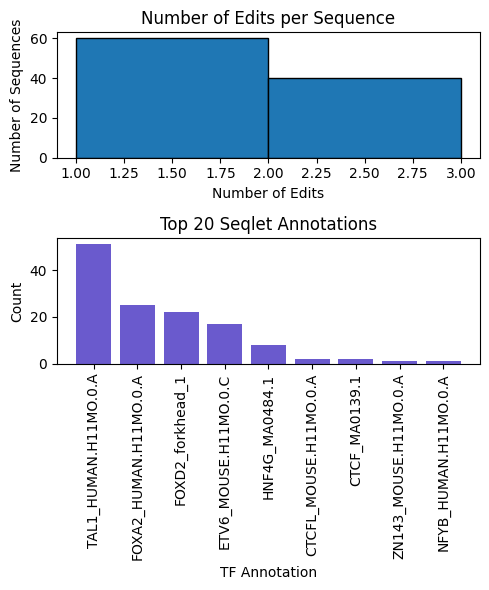

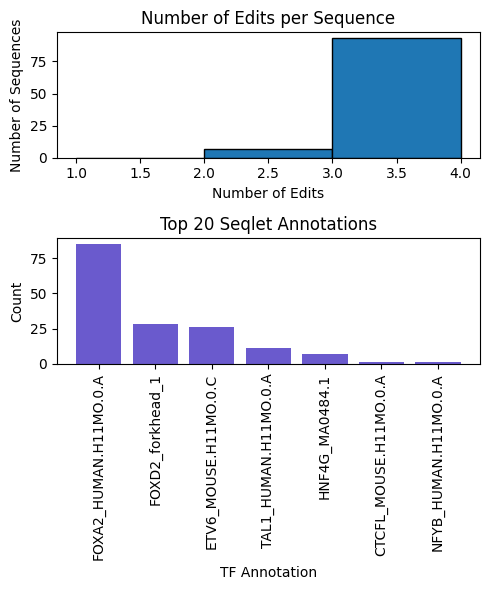

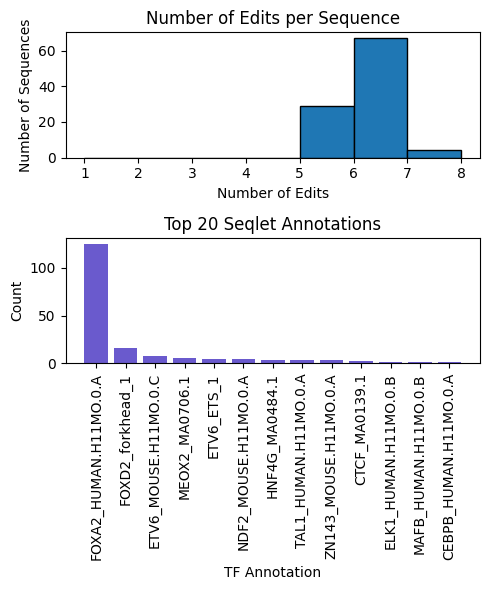

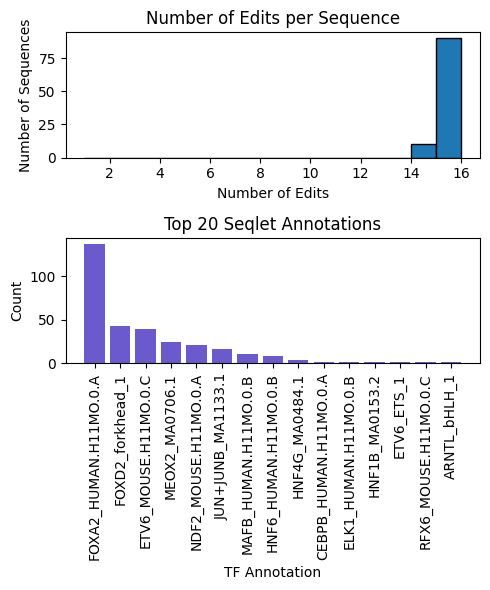

In [94]:
for y_bar in y_bars:

    # Make str
    y_bar_str = f"{y_bar:.2f}"
    
    # Filter dataframes for the current y_bar
    curr_design_df = design_df[design_df["design_target_prediction"] == y_bar_str]
    curr_edit_df = edit_df[edit_df["id"].isin(curr_design_df["id"])]
    curr_seqlets_df = seqlets_df[seqlets_df["id"].isin(curr_design_df["id"])]

    # Count edits per sequence
    edits_per_sequence = curr_edit_df.groupby("id").size().reset_index(name="num_edits")

    # Count TF annotations
    seqlet_annotations = curr_seqlets_df["annotation"].value_counts().reset_index()
    seqlet_annotations.columns = ["annotation", "count"]

    # Plotting
    fig, axes = plt.subplots(2, 1, figsize=(5, 6), facecolor='white')

    # Plot 1: Histogram of number of edits
    axes[0].hist(edits_per_sequence["num_edits"],
                bins=range(1, edits_per_sequence["num_edits"].max() + 2),
                edgecolor='black')
    axes[0].set_title("Number of Edits per Sequence")
    axes[0].set_xlabel("Number of Edits")
    axes[0].set_ylabel("Number of Sequences")
    axes[0].set_facecolor('white')

    # Plot 2: Top 20 TF annotations
    top_annotations = seqlet_annotations.head(20)
    axes[1].bar(top_annotations["annotation"], top_annotations["count"], color="slateblue")
    axes[1].set_title("Top 20 Seqlet Annotations")
    axes[1].set_xlabel("TF Annotation")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_facecolor('white')

    plt.tight_layout()
    plt.show()